In [1]:
using DrWatson
@quickactivate "project"

using DifferentialEquations
using SimpleDiffEq
using Tables
using DataFrames
using StatsPlots
using LaTeXStrings  # Для красивого отображения формул на графиках
using Plots
using BenchmarkTools

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

function sir_ode!(du, u, p, t)
    (S, I, R) = u
    (β, c, γ) = p
    N = S + I + R
    @inbounds begin
        du[1] = -β * c * I / N * S
        du[2] = β * c * I / N * S - γ * I
        du[3] = γ * I
    end
    nothing
end

sir_ode! (generic function with 1 method)

## Определение параметров и расчет
Исследуем влияние числа контактов $c$ на динамику эпидемии.

In [2]:
params_dict = Dict(
    :β => [0.05],            # Вероятность заражения
    :c => [5.0, 10.0, 15.0], # Варианты контактов
    :γ => [0.25]             # Скорость выздоровления
)

dicts = dict_list(params_dict)

3-element Vector{Dict{Symbol, Float64}}:
 Dict(:γ => 0.25, :c => 5.0, :β => 0.05)
 Dict(:γ => 0.25, :c => 10.0, :β => 0.05)
 Dict(:γ => 0.25, :c => 15.0, :β => 0.05)

Общие настройки

In [3]:
δt, tmax = 0.1, 60.0
tspan = (0.0, tmax)
u0 = [990.0, 10.0, 0.0]

3-element Vector{Float64}:
 990.0
  10.0
   0.0

Переменные для хранения финальных результатов (глобальные для Literate)

In [4]:
global sol_ode = nothing
global prob_ode = nothing # Добавили сюда
global df_ode = nothing
global p = []
global R0 = 0.0

0.0

### Цикл моделирования

In [5]:
for (i, d) in enumerate(dicts)
    local_p = [d[:β], d[:c], d[:γ]]
    local_R0 = (local_p[2] * local_p[1]) / local_p[3]

    local_prob = ODEProblem(sir_ode!, u0, tspan, local_p) # Сделали локальной
    local_sol = solve(local_prob, dt = δt)

    # Сохраняем последний прогон для детального анализа ниже
    if i == length(dicts)
        global sol_ode = local_sol
        global prob_ode = local_prob # Обязательно выносим наружу!
        global p = local_p
        global R0 = local_R0
        global df_ode = DataFrame(Tables.table(sol_ode'))
        rename!(df_ode, ["S", "I", "R"])
        df_ode[!, :t] = sol_ode.t
        df_ode[!, :N] = df_ode.S + df_ode.I + df_ode.R
    end

    println("Набор $i: c = $(d[:c]), R₀ = $(round(local_R0, digits=2))")
end

Набор 1: c = 5.0, R₀ = 1.0
Набор 2: c = 10.0, R₀ = 2.0
Набор 3: c = 15.0, R₀ = 3.0


### Цикл моделирования

In [6]:
for (i, d) in enumerate(dicts)
    local_p = [d[:β], d[:c], d[:γ]]
    local_R0 = (local_p[2] * local_p[1]) / local_p[3]

    prob_ode = ODEProblem(sir_ode!, u0, tspan, local_p)
    local_sol = solve(prob_ode, dt = δt)

    # Сохраняем последний прогон для детального анализа ниже
    if i == length(dicts)
        global sol_ode = local_sol
        global p = local_p
        global R0 = local_R0
        global df_ode = DataFrame(Tables.table(sol_ode'))
        rename!(df_ode, ["S", "I", "R"])
        df_ode[!, :t] = sol_ode.t
        df_ode[!, :N] = df_ode.S + df_ode.I + df_ode.R
    end

    println("Набор $i: c = $(d[:c]), R₀ = $(round(local_R0, digits=2))")
end

Набор 1: c = 5.0, R₀ = 1.0
Набор 2: c = 10.0, R₀ = 2.0
Набор 3: c = 15.0, R₀ = 3.0


Вывод параметров модели

In [7]:
println("Параметры модели SIR:")
println("β (вероятность заражения) = ", p[1])
println("c (среднее число контактов) = ", p[2])
println("γ (скорость выздоровления) = ", p[3])
println("R₀ = c * β / γ = ", round(R0, digits=3))
println("Средняя продолжительность болезни = ", round(1/p[3], digits=2), " дней")
println("Начальные условия: S₀ = ", u0[1], ", I₀ = ", u0[2], ", R₀ = ", u0[3])

Параметры модели SIR:
β (вероятность заражения) = 0.05
c (среднее число контактов) = 15.0
γ (скорость выздоровления) = 0.25
R₀ = c * β / γ = 3.0
Средняя продолжительность болезни = 4.0 дней
Начальные условия: S₀ = 990.0, I₀ = 10.0, R₀ = 0.0


1. ОСНОВНОЙ ГРАФИК: динамика всех трех групп

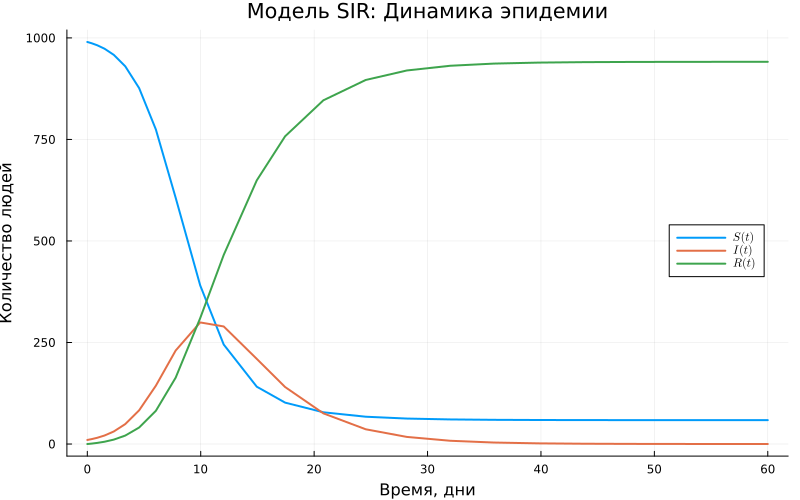

In [8]:
plt1 = @df df_ode plot(:t,
    [:S :I :R],
    label=[L"S(t)" L"I(t)" L"R(t)"],
    xlabel="Время, дни",
    ylabel="Количество людей",
    title="Модель SIR: Динамика эпидемии",
    linewidth=2,
    legend=:right,
    grid=true,
    size=(800, 500))

Добавление аннотаций с параметрами

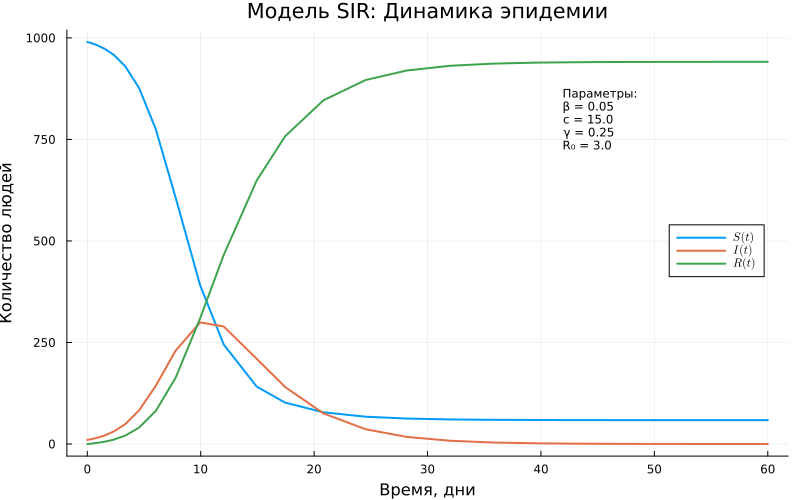

In [9]:
annotate!(plt1, maximum(df_ode.t) * 0.7, maximum(df_ode.N) * 0.8,
    text("Параметры:\nβ = $(p[1])\nc = $(p[2])\nγ = $(p[3])\nR₀ = $(round(R0, digits=2))",
    8, :left))

График только инфицированных (I)

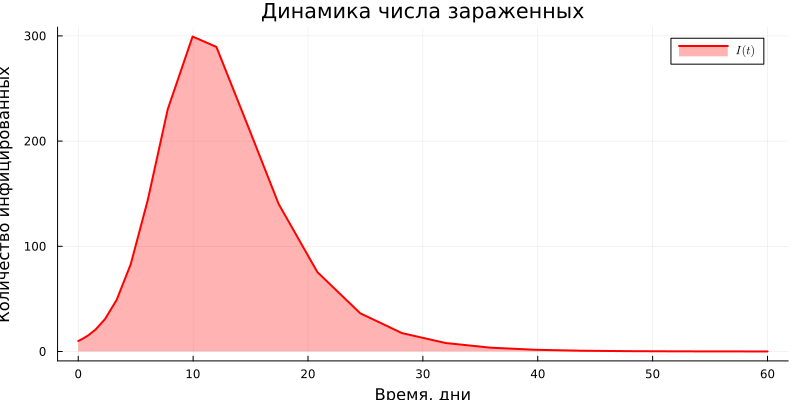

In [10]:
plt2 = @df df_ode plot(:t, :I,
    label=L"I(t)",
    xlabel="Время, дни",
    ylabel="Количество инфицированных",
    title="Динамика числа зараженных",
    color=:red,
    linewidth=2,
    fill=(0, 0.3, :red),
    grid=true,
    size=(800, 400))

Отметка пика эпидемии

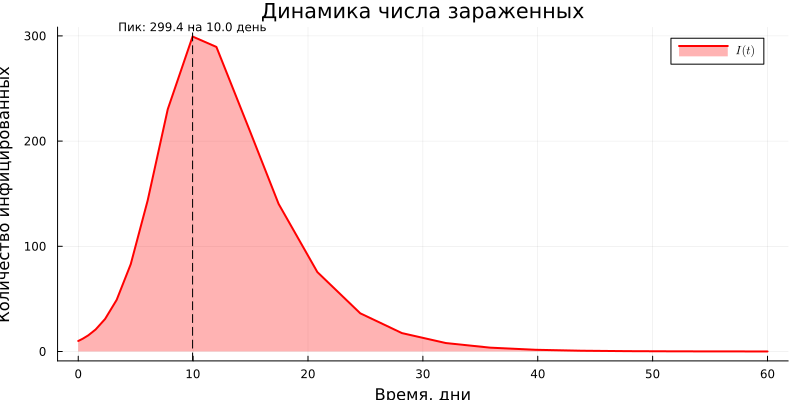

In [11]:
peak_idx = argmax(df_ode.I)
peak_time = df_ode.t[peak_idx]
peak_value = df_ode.I[peak_idx]
vline!(plt2, [peak_time], color=:black, linestyle=:dash, label=false, linewidth=1)
annotate!(plt2, peak_time, peak_value * 1.05,
    text("Пик: $(round(peak_value, digits=1)) на $(round(peak_time, digits=1)) день",
    8, :top))

График в логарифмическом масштабе (для анализа экспоненциального роста)

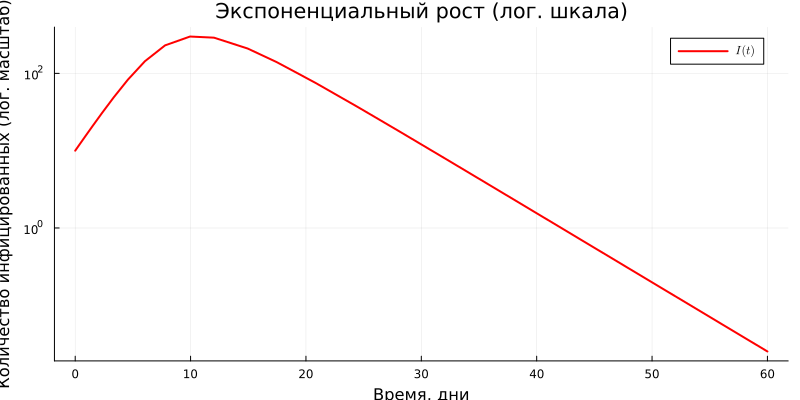

In [12]:
plt3 = @df df_ode plot(:t, :I,
    label=L"I(t)",
    xlabel="Время, дни",
    ylabel="Количество инфицированных (лог. масштаб)",
    title="Экспоненциальный рост (лог. шкала)",
    yscale=:log10,
    color=:red,
    linewidth=2,
    grid=true,
    size=(800, 400))

График долей населения (в процентах)

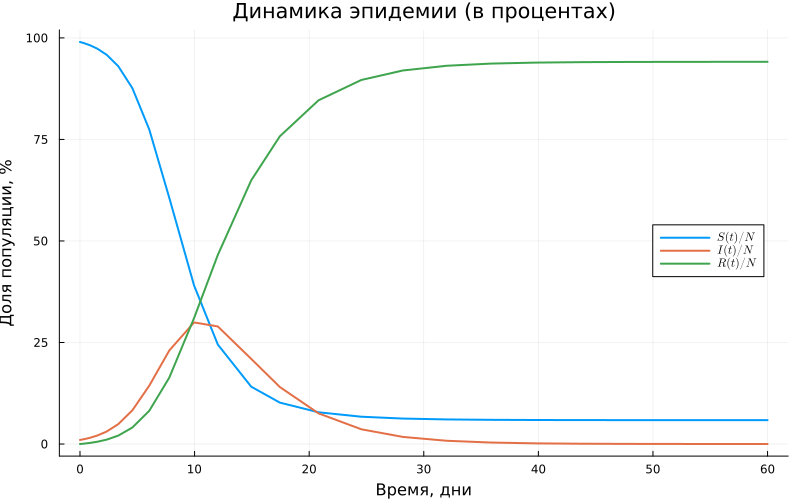

In [13]:
plt4 = @df df_ode plot(:t,
    [:S :I :R] ./ df_ode.N .* 100,
    label=[L"S(t)/N" L"I(t)/N" L"R(t)/N"],
    xlabel="Время, дни",
    ylabel="Доля популяции, %",
    title="Динамика эпидемии (в процентах)",
    linewidth=2,
    legend=:right,
    grid=true,
    size=(800, 500))

Горизонтальная линия для порога коллективного иммунитета

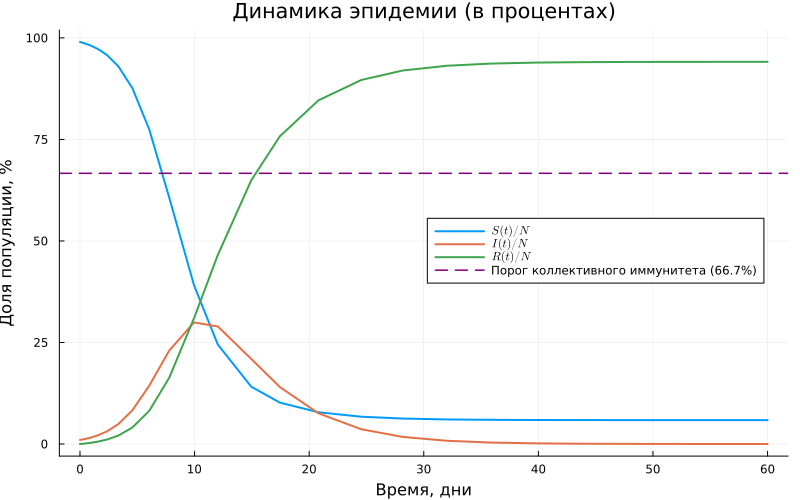

In [14]:
if R0 > 1
    herd_immunity_threshold = (1 - 1/R0) * 100
    hline!(plt4, [herd_immunity_threshold], color=:purple, linestyle=:dash,
        label="Порог коллективного иммунитета ($(round(herd_immunity_threshold, digits=1))%)",
        linewidth=1.5)
end

Фазовый портрет (I vs S)

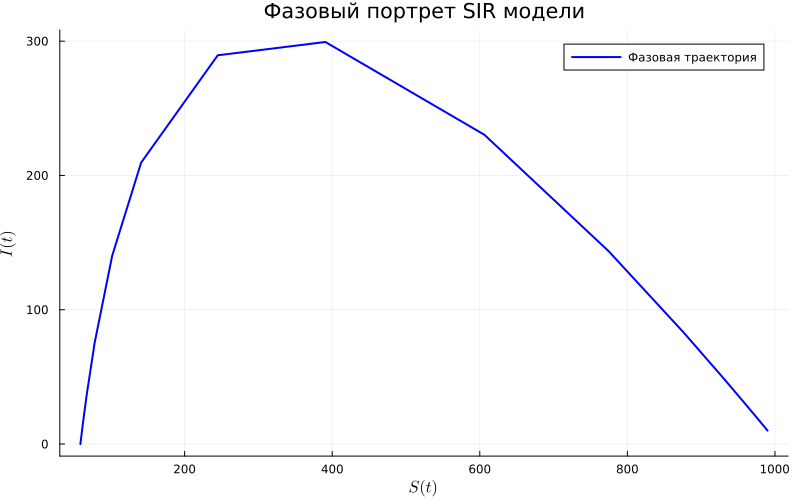

In [15]:
plt5 = plot(df_ode.S, df_ode.I,
    label="Фазовая траектория",
    xlabel=L"S(t)",
    ylabel=L"I(t)",
    title="Фазовый портрет SIR модели",
    color=:blue,
    linewidth=2,
    grid=true,
    size=(800, 500),
    legend=:topright)

Добавление стрелок направления

In [16]:
for i in 1:50:length(df_ode.S)-1
    plot!(plt5, [df_ode.S[i], df_ode.S[i+1]], [df_ode.I[i], df_ode.I[i+1]],
        arrow=:closed, color=:blue, alpha=0.5, label=false)
end

График Rₑ - эффективного репродуктивного числа

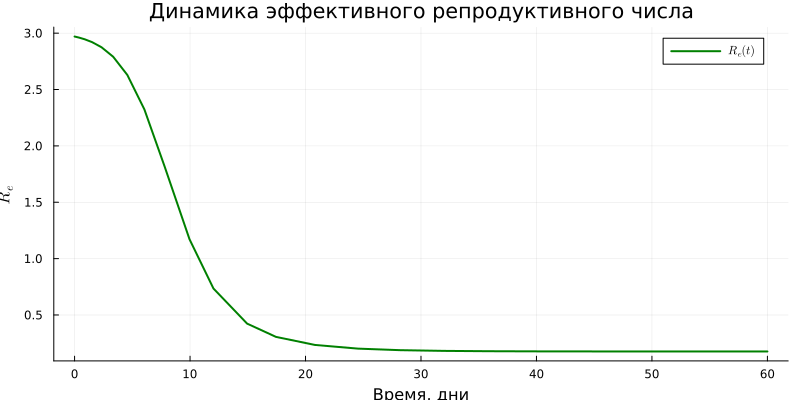

In [17]:
df_ode[!, :Re] = R0 .* df_ode.S ./ df_ode.N
plt6 = @df df_ode plot(:t, :Re,
    label=L"R_e(t)",
    xlabel="Время, дни",
    ylabel=L"R_e",
    title="Динамика эффективного репродуктивного числа",
    color=:green,
    linewidth=2,
    grid=true,
    size=(800, 400))

Горизонтальная линия на уровне 1

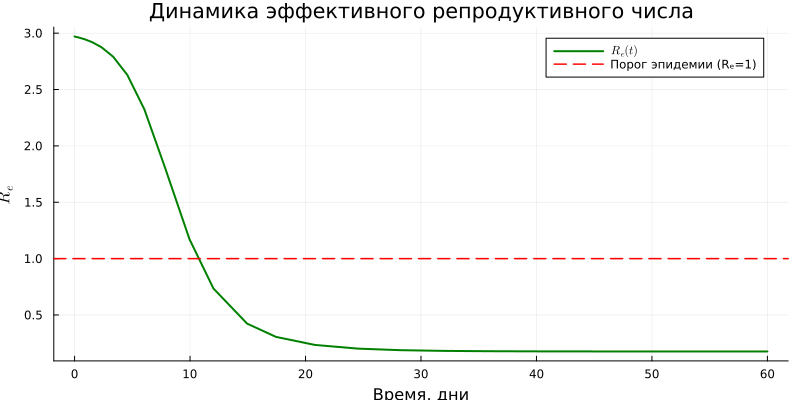

In [18]:
hline!(plt6, [1.0], color=:red, linestyle=:dash, label="Порог эпидемии (Rₑ=1)", linewidth=1.5)

Отметка момента, когда Rₑ становится < 1

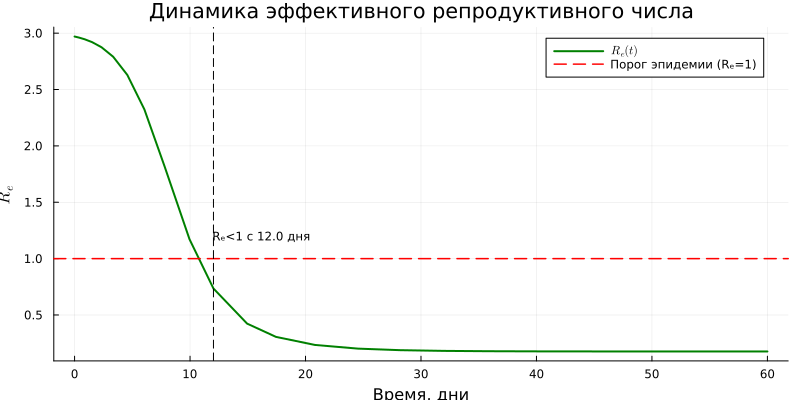

In [19]:
cross_idx = findfirst(x -> x < 1, df_ode.Re)
if !isnothing(cross_idx) && cross_idx > 1
    cross_time = df_ode.t[cross_idx]
    vline!(plt6, [cross_time], color=:black, linestyle=:dash, label=false, linewidth=1)
    annotate!(plt6, cross_time, 1.2,
        text("Rₑ<1 с $(round(cross_time, digits=1)) дня", 8, :left))
end

Компактный график всех кривых в одной панели

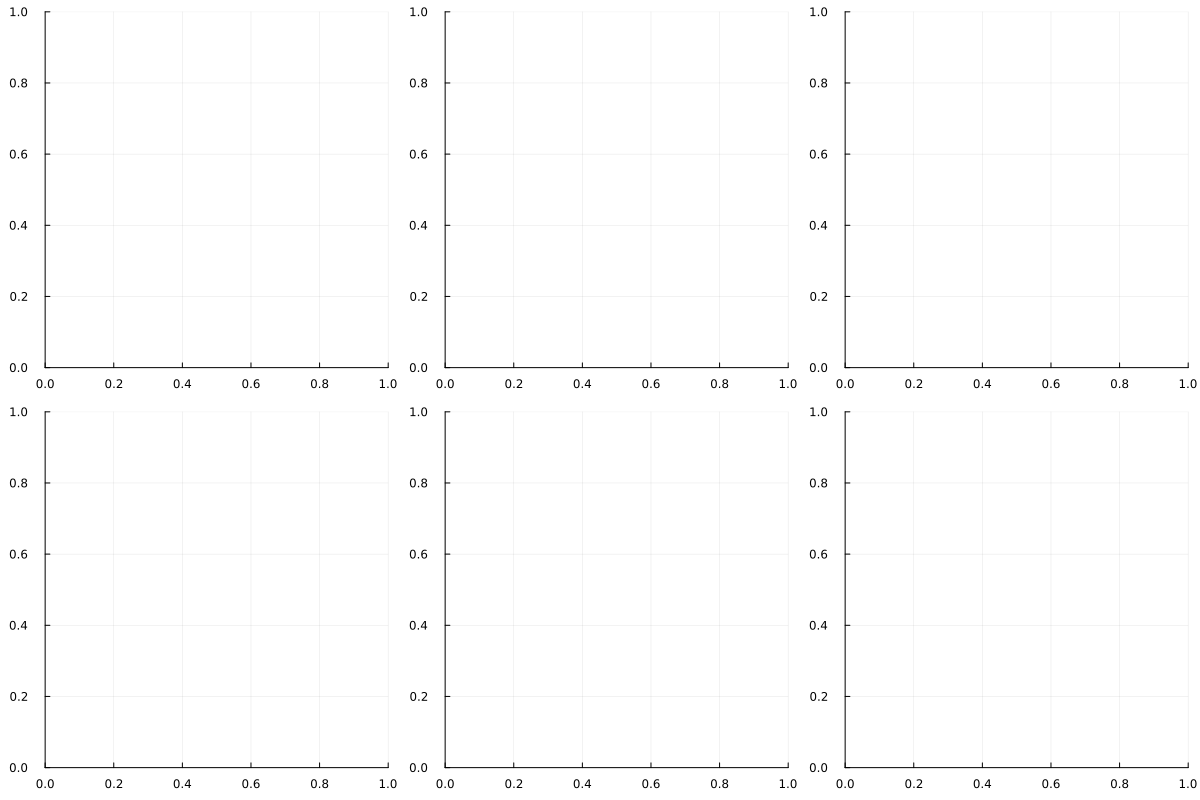

In [20]:
plt7 = plot(layout=(2, 3), size=(1200, 800))

Верхний ряд

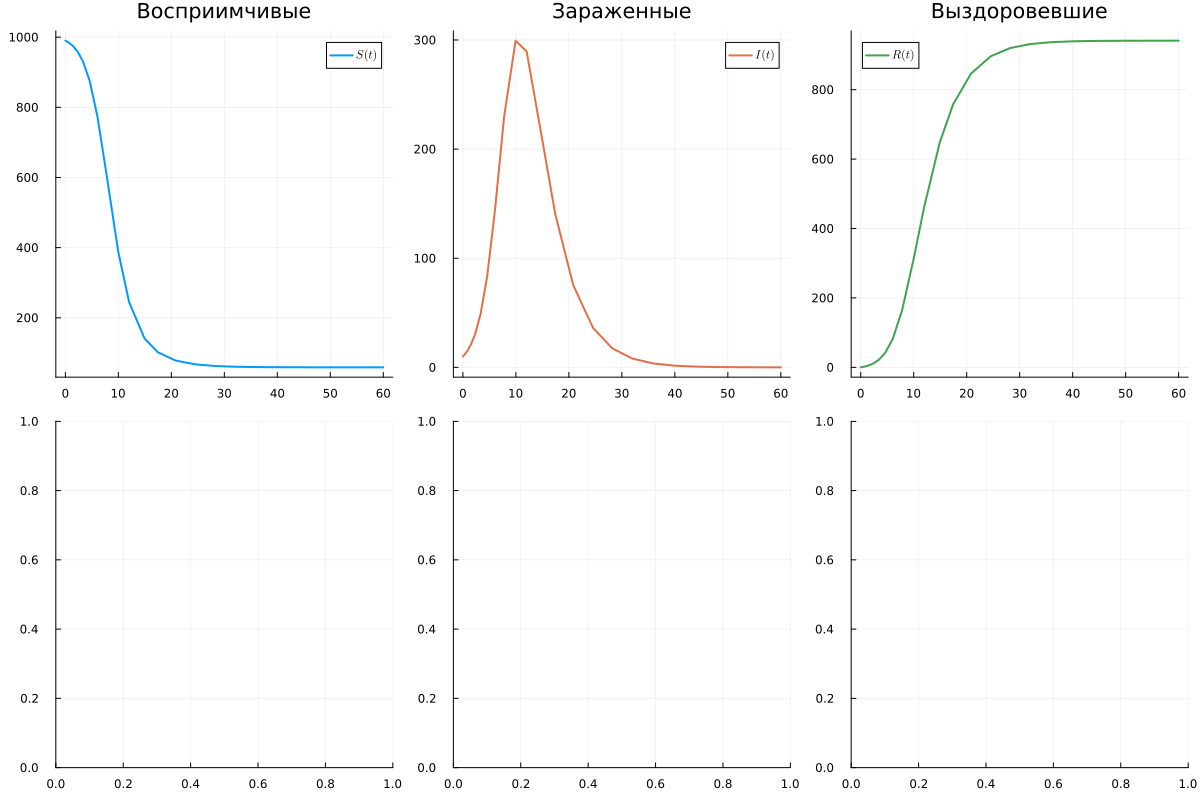

In [21]:
plot!(plt7[1], df_ode.t, df_ode.S, label=L"S(t)", color=1, linewidth=2, title="Восприимчивые")
plot!(plt7[2], df_ode.t, df_ode.I, label=L"I(t)", color=2, linewidth=2, title="Зараженные")
plot!(plt7[3], df_ode.t, df_ode.R, label=L"R(t)", color=3, linewidth=2, title="Выздоровевшие")

Нижний ряд

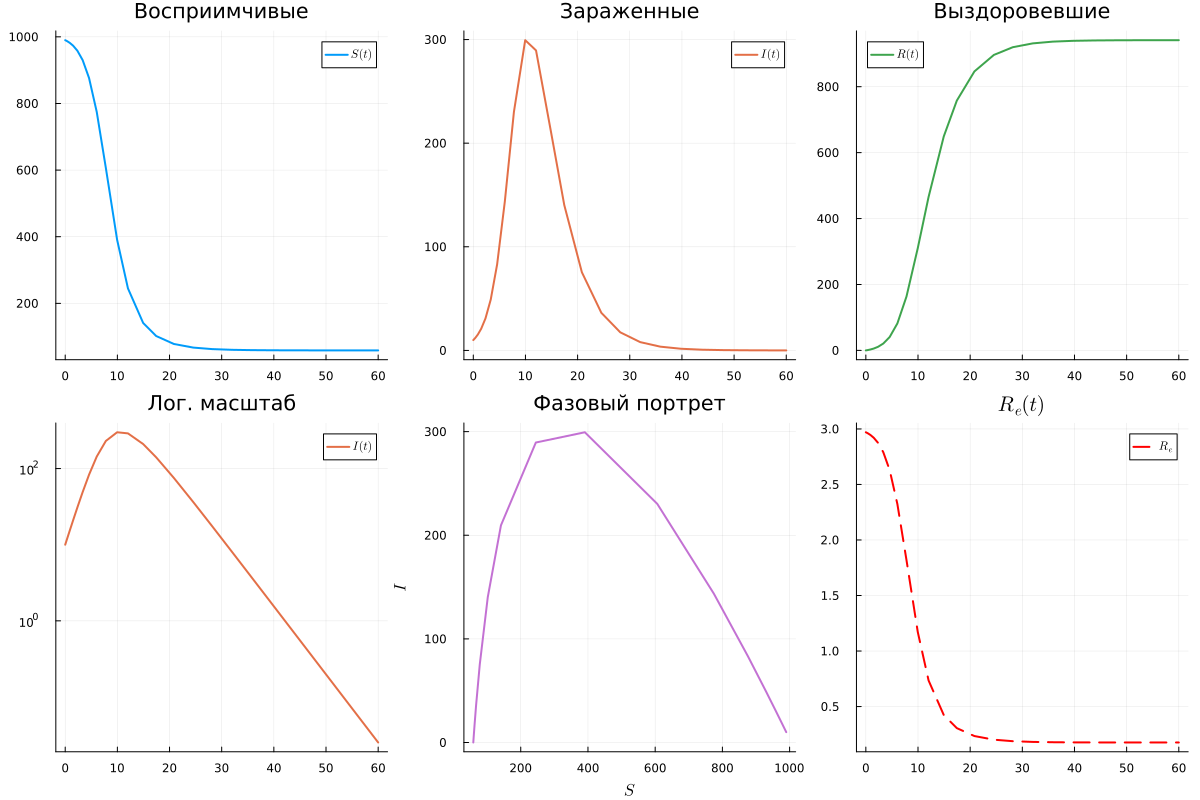

In [22]:
plot!(plt7[4], df_ode.t, df_ode.I, label=L"I(t)", color=2, linewidth=2,
    yscale=:log10, title="Лог. масштаб")
plot!(plt7[5], df_ode.S, df_ode.I, label=false, color=4, linewidth=2,
    title="Фазовый портрет", xlabel=L"S", ylabel=L"I")
plot!(plt7[6], df_ode.t, df_ode.Re, label=L"R_e", color=:green, linewidth=2,
    title=L"R_e(t)", hline=[1.0], linestyle=:dash, linecolor=:red)

Сохранение графиков

In [23]:
savefig(plt1, plotsdir(script_name, "sir_main.png"))
savefig(plt2, plotsdir(script_name, "sir_infected.png"))
savefig(plt3, plotsdir(script_name, "sir_log_scale.png"))
savefig(plt4, plotsdir(script_name, "sir_percentages.png"))
savefig(plt5, plotsdir(script_name, "sir_phase_portrait.png"))
savefig(plt6, plotsdir(script_name, "sir_effective_R.png"))
savefig(plt7, plotsdir(script_name, "sir_panel.png"))

"C:\\visimonova\\work\\study\\2026-1\\2026-1==study--simulation-modeling\\labs\\lab02\\project\\plots\\sir_panel.png"

Бенчмарк для оценки производительности

In [24]:
println("\nБенчмарк решения:")
@benchmark solve(prob_ode, dt = δt)


Бенчмарк решения:


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  13.000 μs …  27.677 ms  ┊ GC (min … max):  0.00% … 99.49%
 Time  (median):     14.900 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   20.278 μs ± 276.650 μs  ┊ GC (mean ± σ):  13.58% ±  0.99%

   ▁█▇▃                                                         
  ▂████▅▃▃▂▃▂▂▂▂▂▂▂▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  13 μs           Histogram: frequency by time         38.3 μs <

 Memory estimate: 25.11 KiB, allocs estimate: 514.

Дополнительный анализ

In [25]:
println("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ===")
println("Общая численность популяции (контроль): N = ", round(df_ode.N[1], digits=1))
println("Пиковое число зараженных: I_max = ", round(peak_value, digits=1))
println("Время достижения пика: t_peak = ", round(peak_time, digits=1), " дней")
println("Итоговое число переболевших: R(∞) = ", round(df_ode.R[end], digits=1))
println("Доля переболевших: ", round(df_ode.R[end]/df_ode.N[1]*100, digits=1), "%")

if R0 > 1
    println("\nТеоретический анализ:")
    println("  - Порог коллективного иммунитета: ", round((1-1/R0)*100, digits=1), "%")
    println("  - Теоретический пик при S/N = 1/R₀ = ", round(1/R0, digits=3))
end


=== АНАЛИЗ РЕЗУЛЬТАТОВ ===
Общая численность популяции (контроль): N = 1000.0
Пиковое число зараженных: I_max = 299.4
Время достижения пика: t_peak = 10.0 дней
Итоговое число переболевших: R(∞) = 941.2
Доля переболевших: 94.1%

Теоретический анализ:
  - Порог коллективного иммунитета: 66.7%
  - Теоретический пик при S/N = 1/R₀ = 0.333


# Анализ модели SIR с разными параметрами
Исследуем влияние вероятности заражения (β) на пик эпидемии.

## Определение набора параметров

In [26]:
beta_values = [0.03, 0.05, 0.08] # Разные значения β
plt_comparison = plot(title="Влияние β на количество инфицированных", xlabel="Время", ylabel="I(t)")

for b in beta_values
    local p_new = [b, 10.0, 0.25] # Обновляем β
    local prob = ODEProblem(sir_ode!, u0, tspan, p_new)
    local sol = solve(prob, dt = δt)

    # Добавляем кривую на общий график
    plot!(plt_comparison, sol.t, [u[2] for u in sol.u], label="β = $b", linewidth=2)
end

## Отображение и сохранение результата
Сохраняем сравнительный график

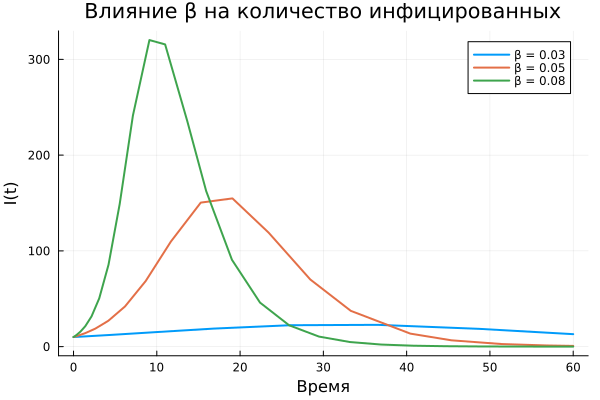

In [27]:
savefig(plt_comparison, plotsdir(script_name, "comparison_beta.png"))
plt_comparison

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*